# Snabb EDA: Flyttningar per kommun (SCB)

**Fråga:** Går det att förutsäga om en kommun får positivt flyttningsnetto nästa år, utifrån tidigare flyttmönster?

#**Källa:** SCB, Statistikdatabasen, tabell BE0101J/Flyttningar97 "Flyttningar efter region, ålder, kön, tabellinnehåll och år" (1997–2024)
https://www.statistikdatabasen.scb.se/pxweb/sv/ssd/START__BE__BE0101__BE0101J/Flyttningar97/
**Licens:** CC0 (SCB:s öppna data sedan 2021)

Datan hämtas via SCB:s API (PxWeb) och sparas i `data/raw/scb/`, så att hämtningen bara görs en gång. API:et har en gräns för antal värden per anrop och antal anrop per tidsenhet, därför görs hämtningen i flera mindre anrop.

In [1]:
import json
import time
import urllib.request
from pathlib import Path
 
import pandas as pd
import matplotlib.pyplot as plt
 
API = "https://api.scb.se/OV0104/v1/doris/sv/ssd/START/BE/BE0101/BE0101J/Flyttningar97"
RAW_DIR = Path("../data/raw/scb")
RAW_DIR.mkdir(parents=True, exist_ok=True)
 
CONTENTS = {
    "BE0101AU": "inflyttningar",
    "BE0101AV": "utflyttningar",
    "BE0101AX": "invandringar",
    "BE0101AY": "utvandringar",
    "BE0101AZ": "flyttningsnetto",
    "BE0101A1": "invandringsnetto",
    "BE0101A2": "inrikes_inflyttningar",
    "BE0101A3": "inrikes_utflyttningar",
    "BE0101A4": "inrikes_flyttningsnetto",
}
 
 
def _read(response):
    # SCB:s svar kan börja med ett BOM-tecken, därför utf-8-sig
    return json.loads(response.read().decode("utf-8-sig"))
 
 
def get_metadata():
    with urllib.request.urlopen(API) as r:
        return _read(r)
 
 
def query(selections):
    """Hämta data. selections = {variabelkod: [värden]}. Utelämnade variabler summeras."""
    body = {
        "query": [{"code": code, "selection": {"filter": "item", "values": values}}
                  for code, values in selections.items()],
        "response": {"format": "json"},
    }
    req = urllib.request.Request(API, data=json.dumps(body).encode("utf-8"),
                                 headers={"Content-Type": "application/json"})
    with urllib.request.urlopen(req) as r:
        result = _read(r)
    time.sleep(1.1)  # SCB tillåter ungefär 10 anrop per 10 sekunder
 
    dims = [c["code"] for c in result["columns"] if c["type"] in ("d", "t")]
    vals = [c["code"] for c in result["columns"] if c["type"] == "c"]
    df = pd.DataFrame([row["key"] + row["values"] for row in result["data"]],
                      columns=dims + vals)
    for v in vals:
        df[v] = pd.to_numeric(df[v], errors="coerce")
    return df.rename(columns=CONTENTS)

## Metadata: regioner och år

In [2]:
meta = get_metadata()
variables = {v["code"]: v for v in meta["variables"]}
 
regions = pd.DataFrame({"kod": variables["Region"]["values"],
                        "namn": variables["Region"]["valueTexts"]})
years = variables["Tid"]["values"]
 
# Kommuner har fyrsiffrig kod. Riket ("00"), län (två siffror) och
# koder som börjar på "00" (t.ex. storstadsområden) tas bort.
kommuner = regions[(regions["kod"].str.len() == 4) & ~regions["kod"].str.startswith("00")]
print("Regioner i tabellen:", len(regions))
print("Kommuner:", len(kommuner))
print("År:", years[0], "-", years[-1])
print(regions[~regions["kod"].isin(kommuner["kod"])])  # det som filtrerades bort
 
KOMMUN_CODES = kommuner["kod"].tolist()

Regioner i tabellen: 315
Kommuner: 290
År: 1997 - 2024
      kod                  namn
0      00                 Riket
1    0010        Stor-Stockholm
2    0020         Stor-Göteborg
3    0030            Stor-Malmö
4      01        Stockholms län
31     03           Uppsala län
40     04     Södermanlands län
50     05     Östergötlands län
64     06        Jönköpings län
78     07        Kronobergs län
87     08            Kalmar län
100    09          Gotlands län
102    10          Blekinge län
108    12             Skåne län
142    13          Hallands län
149    14  Västra Götalands län
199    17         Värmlands län
216    18            Örebro län
229    19      Västmanlands län
240    20          Dalarnas län
256    21        Gävleborgs län
267    22   Västernorrlands län
275    23         Jämtlands län
284    24     Västerbottens län
300    25       Norrbottens län


## Hämtning
1. **Totaler:** alla åldrar och båda könen sammanslagna, alla nio mått.
2. **Per kön:** alla åldrar sammanslagna, fyra grundmått.
3. **Per ålder:** båda könen sammanslagna, fyra grundmått, ett anrop per år.

In [3]:
BASE = ["BE0101A2", "BE0101A3", "BE0101AX", "BE0101AY"]  # inrikes in/ut, in-/utvandring
 
totals_path = RAW_DIR / "flyttningar_totaler.csv"
if not totals_path.exists():
    query({"Region": KOMMUN_CODES, "Alder": ["tot"],
           "ContentsCode": list(CONTENTS), "Tid": years}).to_csv(totals_path, index=False)
 
gender_path = RAW_DIR / "flyttningar_kon.csv"
if not gender_path.exists():
    query({"Region": KOMMUN_CODES, "Alder": ["tot"], "Kon": ["1", "2"],
           "ContentsCode": BASE, "Tid": years}).to_csv(gender_path, index=False)
 
age_path = RAW_DIR / "flyttningar_alder.csv"
if not age_path.exists():
    ages = [a for a in variables["Alder"]["values"] if a != "tot"]
    parts = []
    for year in years:
        print("Hämtar åldrar", year)
        parts.append(query({"Region": KOMMUN_CODES, "Alder": ages,
                            "ContentsCode": BASE, "Tid": [year]}))
    pd.concat(parts).to_csv(age_path, index=False)
 
totals = pd.read_csv(totals_path, dtype={"Region": str})
by_gender = pd.read_csv(gender_path, dtype={"Region": str, "Kon": str})
by_age = pd.read_csv(age_path, dtype={"Region": str, "Alder": str})
 
for name, d in [("Totaler", totals), ("Per kön", by_gender), ("Per ålder", by_age)]:
    print(f"{name}: {d.shape}")

Hämtar åldrar 1997
Hämtar åldrar 1998
Hämtar åldrar 1999
Hämtar åldrar 2000
Hämtar åldrar 2001
Hämtar åldrar 2002
Hämtar åldrar 2003
Hämtar åldrar 2004
Hämtar åldrar 2005
Hämtar åldrar 2006
Hämtar åldrar 2007
Hämtar åldrar 2008
Hämtar åldrar 2009
Hämtar åldrar 2010
Hämtar åldrar 2011
Hämtar åldrar 2012
Hämtar åldrar 2013
Hämtar åldrar 2014
Hämtar åldrar 2015
Hämtar åldrar 2016
Hämtar åldrar 2017
Hämtar åldrar 2018
Hämtar åldrar 2019
Hämtar åldrar 2020
Hämtar åldrar 2021
Hämtar åldrar 2022
Hämtar åldrar 2023
Hämtar åldrar 2024
Totaler: (8120, 12)
Per kön: (16240, 8)
Per ålder: (820120, 7)


## Översikt och datakvalitet

In [4]:
totals = totals.rename(columns={"Region": "kod", "Tid": "ar"})
totals = totals.merge(kommuner, on="kod", how="left")
totals.info()
 
print("\nKommuner per år:")
print(totals.groupby("ar")["kod"].nunique().describe())

# Kommuner som bildats eller ändrats efter 1997 kan ha nollor eller saknade värden
all_zero = totals[CONTENTS.values()].fillna(0).eq(0).all(axis=1)
print("\nRader där alla mått är noll eller saknas:", all_zero.sum())
print(totals.loc[all_zero, ["namn", "ar"]].groupby("namn")["ar"].agg(["min", "max", "count"]))

<class 'pandas.DataFrame'>
RangeIndex: 8120 entries, 0 to 8119
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   kod                      8120 non-null   str  
 1   Alder                    8120 non-null   str  
 2   ar                       8120 non-null   int64
 3   inflyttningar            8120 non-null   int64
 4   utflyttningar            8120 non-null   int64
 5   invandringar             8120 non-null   int64
 6   utvandringar             8120 non-null   int64
 7   flyttningsnetto          8120 non-null   int64
 8   invandringsnetto         8120 non-null   int64
 9   inrikes_inflyttningar    8120 non-null   int64
 10  inrikes_utflyttningar    8120 non-null   int64
 11  inrikes_flyttningsnetto  8120 non-null   int64
 12  namn                     8120 non-null   str  
dtypes: int64(10), str(3)
memory usage: 824.8 KB

Kommuner per år:
count     28.0
mean     290.0
std        0.0
min      290

In [5]:
print(totals[list(CONTENTS.values())].describe().round(0).T)

                          count    mean     std      min    25%    50%  \
inflyttningar            8120.0  1914.0  4524.0      0.0  485.0  850.0   
utflyttningar            8120.0  1750.0  4130.0      0.0  488.0  818.0   
invandringar             8120.0   325.0  1033.0      0.0   56.0  116.0   
utvandringar             8120.0   160.0   591.0      0.0   22.0   46.0   
flyttningsnetto          8120.0   164.0   553.0  -4966.0  -25.0   42.0   
invandringsnetto         8120.0   164.0   487.0   -269.0   23.0   59.0   
inrikes_inflyttningar    8120.0  1590.0  3531.0      0.0  408.0  729.0   
inrikes_utflyttningar    8120.0  1590.0  3564.0      0.0  458.0  773.0   
inrikes_flyttningsnetto  8120.0     0.0   355.0 -11399.0  -91.0  -25.0   

                            75%      max  
inflyttningar            1696.0  73478.0  
utflyttningar            1510.0  78058.0  
invandringar              258.0  18717.0  
utvandringar              108.0  12808.0  
flyttningsnetto           178.0  13054.0  
i

## Målvariabel: positivt flyttningsnetto nästa år
Två varianter jämförs:
- **Totalt flyttningsnetto:** inkluderar invandring, som påverkas starkt av politik och flyktingmottagande.
- **Inrikes flyttningsnetto:** bara flyttningar inom Sverige, speglar bättre hur attraktiv kommunen är.

      flyttningsnetto_positiv  inrikes_flyttningsnetto_positiv
ar                                                            
1997                     0.30                             0.30
1998                     0.31                             0.28
1999                     0.34                             0.30
2000                     0.45                             0.32
2001                     0.54                             0.37
2002                     0.62                             0.43
2003                     0.70                             0.48
2004                     0.65                             0.46
2005                     0.61                             0.41
2006                     0.69                             0.38
2007                     0.69                             0.40
2008                     0.63                             0.33
2009                     0.62                             0.33
2010                     0.60                          

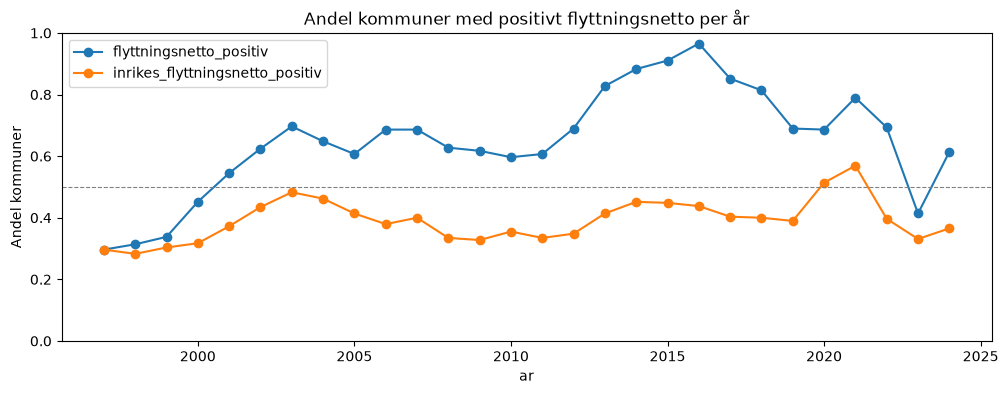

In [6]:
totals = totals.sort_values(["kod", "ar"])
for col in ["flyttningsnetto", "inrikes_flyttningsnetto"]:
    totals[f"{col}_positiv"] = (totals[col] > 0).astype(int)
    # Målet: tecknet NÄSTA år. Sista året saknar därför mål.
    totals[f"mal_{col}"] = totals.groupby("kod")[f"{col}_positiv"].shift(-1)
 
share = totals.groupby("ar")[["flyttningsnetto_positiv", "inrikes_flyttningsnetto_positiv"]].mean()
print(share.round(2))
 
share.plot(figsize=(12, 4), marker="o",
           title="Andel kommuner med positivt flyttningsnetto per år")
plt.ylabel("Andel kommuner")
plt.ylim(0, 1)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
plt.show()

## Den naiva baselinen: samma tecken som i år
Hur ofta har en kommun samma tecken på flyttningsnettot nästa år som i år?
Detta är den lägsta nivån en modell måste slå.

flyttningsnetto: samma tecken nästa år i 74.0% av fallen
inrikes_flyttningsnetto: samma tecken nästa år i 75.7% av fallen


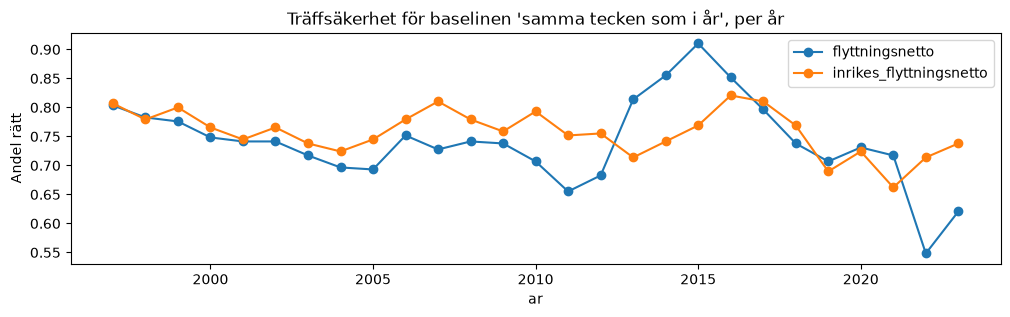

In [7]:
for col in ["flyttningsnetto", "inrikes_flyttningsnetto"]:
    d = totals.dropna(subset=[f"mal_{col}"])
    same = (d[f"{col}_positiv"] == d[f"mal_{col}"])
    print(f"{col}: samma tecken nästa år i {same.mean():.1%} av fallen")
 
    per_year = same.groupby(d["ar"]).mean()
    per_year.plot(figsize=(12, 3), marker="o", label=col)
 
plt.title("Träffsäkerhet för baselinen 'samma tecken som i år', per år")
plt.ylabel("Andel rätt")
plt.legend()
plt.show()

## Ålder: var kommer flyttningarna ifrån?

Andel kommuner med positivt inrikes netto per åldersgrupp, 2024:
aldersgrupp
0-17     0.57
18-24    0.09
25-34    0.58
35-49    0.59
50-64    0.57
65+      0.45
Name: inrikes_netto, dtype: float64


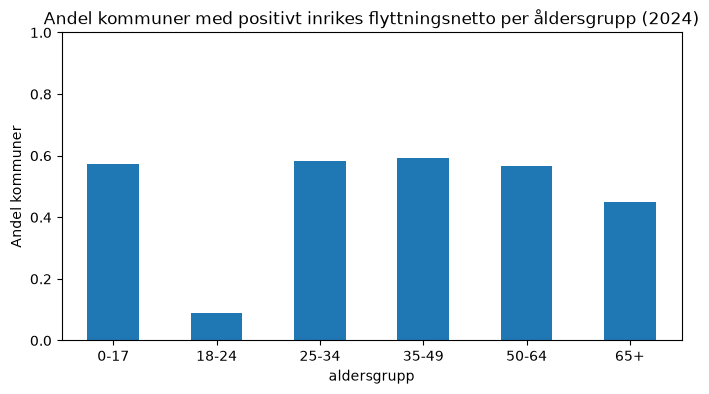

In [8]:
bins = [-1, 17, 24, 34, 49, 64, 200]
labels = ["0-17", "18-24", "25-34", "35-49", "50-64", "65+"]
 
by_age["alder_num"] = by_age["Alder"].str.replace("+", "", regex=False).astype(int)
by_age["aldersgrupp"] = pd.cut(by_age["alder_num"], bins=bins, labels=labels)
by_age["inrikes_netto"] = by_age["inrikes_inflyttningar"] - by_age["inrikes_utflyttningar"]
 
age_groups = (by_age.groupby(["Region", "Tid", "aldersgrupp"], observed=True)["inrikes_netto"]
              .sum().reset_index())
 
latest = age_groups["Tid"].max()
pos_share = (age_groups[age_groups["Tid"] == latest]
             .groupby("aldersgrupp", observed=True)["inrikes_netto"]
             .apply(lambda s: (s > 0).mean()))
print(f"Andel kommuner med positivt inrikes netto per åldersgrupp, {latest}:")
print(pos_share.round(2))
 
pos_share.plot(kind="bar", figsize=(8, 4),
               title=f"Andel kommuner med positivt inrikes flyttningsnetto per åldersgrupp ({latest})")
plt.ylabel("Andel kommuner")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## Kön

In [9]:
by_gender["inrikes_netto"] = by_gender["inrikes_inflyttningar"] - by_gender["inrikes_utflyttningar"]
wide = by_gender.pivot_table(index=["Region", "Tid"], columns="Kon", values="inrikes_netto")
wide.columns = ["man", "kvinnor"]
print("Korrelation mellan mäns och kvinnors inrikes netto:", round(wide.corr().iloc[0, 1], 2))
print("Andel kommun-år där män och kvinnor har samma tecken:",
      f"{(((wide['man'] > 0) == (wide['kvinnor'] > 0)).mean()):.1%}")

Korrelation mellan mäns och kvinnors inrikes netto: 0.94
Andel kommun-år där män och kvinnor har samma tecken: 83.3%


## Exempel: några kommuners inrikes flyttningsnetto över tid

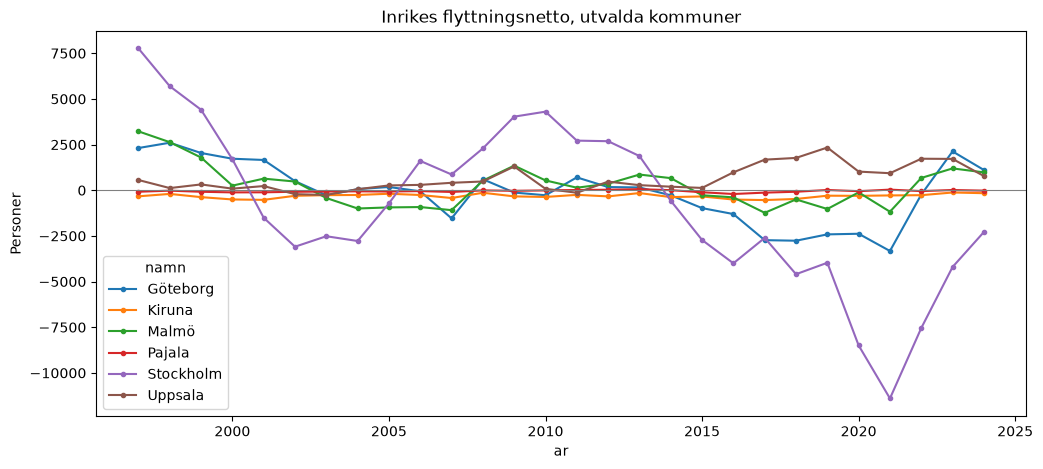

In [10]:
examples = ["Stockholm", "Göteborg", "Malmö", "Kiruna", "Pajala", "Uppsala"]
ex = totals[totals["namn"].isin(examples)].pivot(index="ar", columns="namn",
                                                 values="inrikes_flyttningsnetto")
ex.plot(figsize=(12, 5), marker=".", title="Inrikes flyttningsnetto, utvalda kommuner")
plt.axhline(0, color="gray", linewidth=0.8)
plt.ylabel("Personer")
plt.show()

## Sammanfattning av EDA

### Datan
- 290 kommuner × 28 år (1997–2024) = 8 120 rader, inga saknade värden. Licens CC0 (SCB).
- Knivsta (1997–2002) och Nykvarn (1997–1998) har bara nollor eftersom kommunerna bildades senare. Tas bort.
- Inrikes flyttningsnetto har medelvärdet exakt 0, som förväntat eftersom inrikes flyttningar tar ut varandra. Kontroll av att datan är komplett.

### Målvariabel
- **Totalt flyttningsnetto** svänger kraftigt med invandringen: 30–96 % av kommunerna positiva beroende på år. Svårt att förutsäga från flyttmönster.
- **Inrikes flyttningsnetto** är stabilare: 30–57 % positiva. **Föreslås som mål.**

### Baseline
- "Samma tecken som i år": **75,7 %** rätt (inrikes), 74,0 % (totalt).
- "Alltid negativt": ca 60 % rätt (inrikes).
- Baselinen för inrikes ligger mellan 66 och 82 % beroende på år.

### Variabler
- Ålder är informativ: bara 9 % av kommunerna har positivt netto för 18–24-åringar (2024).
- Kön tillför lite: korrelation 0,94 mellan män och kvinnor.
- Absoluta tal beror på kommunens storlek. Skalfria variabler behövs, t.ex. netto / (inflyttningar + utflyttningar).

### Risker
- Många kommuner har netto nära noll, där tecknet är nästan slumpmässigt.
- Pandemin (2020–2021) påverkade flyttmönstren, t.ex. Stockholms stora utflyttning, och ingår i testperioden.